In [ ]:
# Instalação das bibliotecas

!pip -q install sentence-transformers
!pip -q install transformers
!pip -q install accelerate
!pip -q install umap-learn
!pip -q install wordcloud
!pip install -q nltk

In [ ]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re

from tqdm.auto import tqdm

import torch

In [ ]:
from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score

from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud

import umap.umap_ as umap

In [ ]:
print("="*60)

print("PyTorch:",torch.__version__)

print("GPU disponível:",torch.cuda.is_available())

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))

print("="*60)

PyTorch: 2.11.0+cu128
GPU disponível: True
Tesla T4


In [ ]:
import pandas as pd

df = pd.read_csv(
    "articles.csv",
    engine="python",
    on_bad_lines="skip"
)

print(df.shape)

(167053, 6)


In [ ]:
print(df.shape)

df.head()

(167053, 6)


,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167053 entries, 0 to 167052
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   title        167053 non-null  object
 1   text         166288 non-null  object
 2   date         167053 non-null  object
 3   category     167053 non-null  object
 4   subcategory  29635 non-null   object
 5   link         167053 non-null  object
dtypes: object(6)
memory usage: 7.6+ MB


In [ ]:
df = df[["title", "text", "category"]]

In [ ]:
df = df.dropna()

df.shape

(166288, 3)

In [ ]:
df["conteudo"] = (
    df["title"]
    + ". "
    + df["text"].str[:500]
)

In [ ]:
df = (
    df
    .sample(
        10000,
        random_state=42
    )
    .reset_index(drop=True)
)

In [ ]:
import re

from nltk.corpus import stopwords

stop_words = stopwords.words("portuguese")

def limpar_texto(texto):

    texto = texto.lower()

    texto = re.sub(r"http\S+", "", texto)

    texto = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", texto)

    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()

df["texto_limpo"] = df["conteudo"].apply(limpar_texto)

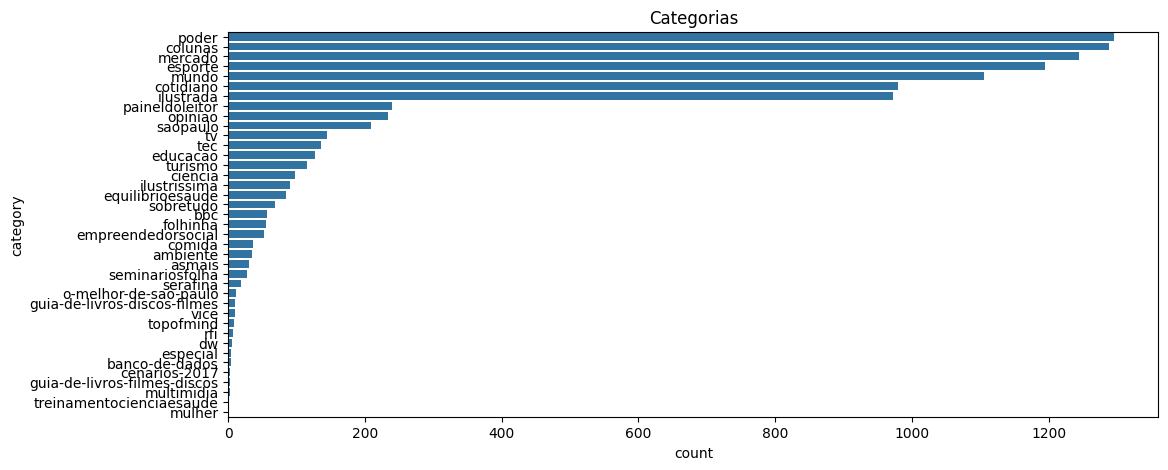

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    y="category",
    order=df.category.value_counts().index
)

plt.title("Categorias")

plt.show()

In [ ]:
df["num_caracteres"] = df["conteudo"].str.len()

df["num_palavras"] = df["conteudo"].str.split().str.len()

In [ ]:
df[["num_caracteres","num_palavras"]].describe()

,num_caracteres,num_palavras
count,10000.000000,10000.000000
mean,557.304800,91.699400
std,44.072771,8.889474
min,47.000000,6.000000
25%,559.000000,88.000000
50%,568.000000,93.000000
75%,573.000000,97.000000
max,631.000000,114.000000


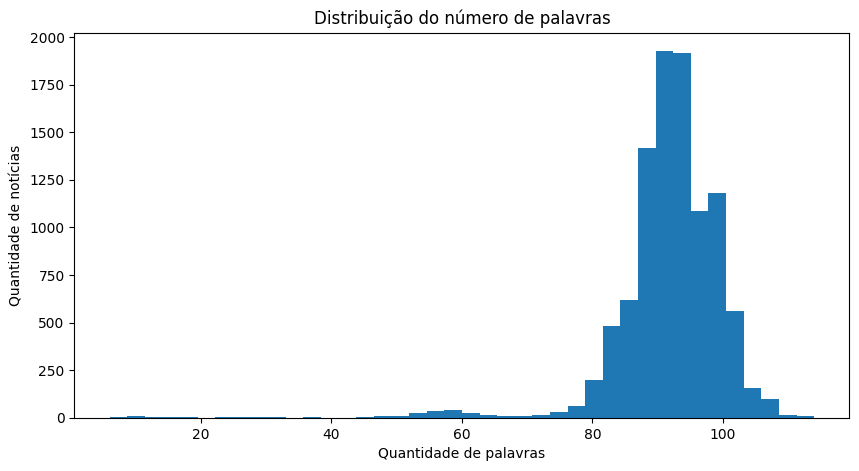

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    df["num_palavras"],
    bins=40
)

plt.title("Distribuição do número de palavras")

plt.xlabel("Quantidade de palavras")

plt.ylabel("Quantidade de notícias")

plt.show()

In [ ]:
print("Menor notícia:",df["num_palavras"].min(),"palavras")
print("Maior notícia:",df["num_palavras"].max(),"palavras")
print("Média:",round(df["num_palavras"].mean(),1),"palavras")

Menor notícia: 6 palavras
Maior notícia: 114 palavras
Média: 91.7 palavras


# Geração dos Embeddings

Será utilizado um modelo Sentence Transformer multilíngue, capaz de gerar representações semânticas para textos em português.

In [ ]:
modelo = SentenceTransformer(
    "paraphrase-multilingual-mpnet-base-v2",
    device="cuda"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
embeddings = modelo.encode(
    df["conteudo"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [ ]:
print(embeddings.shape)

(10000, 768)


In [ ]:
np.save(
    "embeddings.npy",
    embeddings
)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(
    embeddings[:10]
)

np.round(sim,2)

array([[ 1.  ,  0.27,  0.13,  0.11,  0.2 ,  0.23,  0.31,  0.15,  0.04,
         0.3 ],
       [ 0.27,  1.  ,  0.24,  0.36,  0.17,  0.25,  0.26,  0.15,  0.09,
         0.18],
       [ 0.13,  0.24,  1.  ,  0.16, -0.04,  0.08,  0.07,  0.21,  0.1 ,
         0.02],
       [ 0.11,  0.36,  0.16,  1.  ,  0.28,  0.17,  0.32,  0.05,  0.03,
         0.03],
       [ 0.2 ,  0.17, -0.04,  0.28,  1.  ,  0.36,  0.6 ,  0.23,  0.07,
         0.08],
       [ 0.23,  0.25,  0.08,  0.17,  0.36,  1.  ,  0.5 ,  0.34,  0.13,
         0.05],
       [ 0.31,  0.26,  0.07,  0.32,  0.6 ,  0.5 ,  1.  ,  0.28,  0.14,
         0.06],
       [ 0.15,  0.15,  0.21,  0.05,  0.23,  0.34,  0.28,  1.  ,  0.21,
         0.11],
       [ 0.04,  0.09,  0.1 ,  0.03,  0.07,  0.13,  0.14,  0.21,  1.  ,
         0.07],
       [ 0.3 ,  0.18,  0.02,  0.03,  0.08,  0.05,  0.06,  0.11,  0.07,
         1.  ]], dtype=float32)

In [ ]:
sim_total = cosine_similarity(embeddings)

mascara = np.triu(
    np.ones(sim_total.shape),
    k=1
).astype(bool)

print(
    "Similaridade média:",
    sim_total[mascara].mean()
)

Similaridade média: 0.2610329


In [ ]:
pca = PCA(
    n_components=50,
    random_state=42
)

embeddings_pca = pca.fit_transform(
    embeddings
)

print(embeddings_pca.shape)

(10000, 50)


In [ ]:
variancia = np.sum(
    pca.explained_variance_ratio_
)

print(
    f"Variância explicada: {variancia:.2%}"
)

Variância explicada: 63.18%


In [ ]:
scores = []

K = range(2,11)

for k in tqdm(K):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = modelo.fit_predict(
        embeddings_pca
    )

    score = silhouette_score(
        embeddings_pca,
        labels
    )

    scores.append(score)

  0%|          | 0/9 [00:00<?, ?it/s]

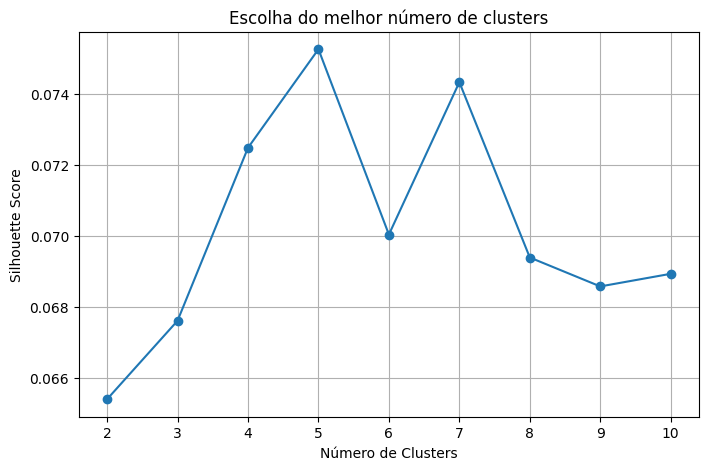

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    scores,
    marker="o"
)

plt.xlabel("Número de Clusters")

plt.ylabel("Silhouette Score")

plt.title("Escolha do melhor número de clusters")

plt.grid()

plt.show()

In [ ]:
for k,score in zip(K,scores):

    print(f"K={k}: {score:.4f}")

K=2: 0.0654
K=3: 0.0676
K=4: 0.0725
K=5: 0.0753
K=6: 0.0700
K=7: 0.0743
K=8: 0.0694
K=9: 0.0686
K=10: 0.0689


In [ ]:
melhor_k = K[np.argmax(scores)]

print(f"Melhor K encontrado: {melhor_k}")

Melhor K encontrado: 5


In [ ]:
kmeans = KMeans(
    n_clusters=melhor_k,
    random_state=42,
    n_init=20
)

df["cluster"] = kmeans.fit_predict(embeddings_pca)

In [ ]:
df["cluster"].value_counts().sort_index()

,count
cluster,
0,2448
1,2373
2,2092
3,2018
4,1069


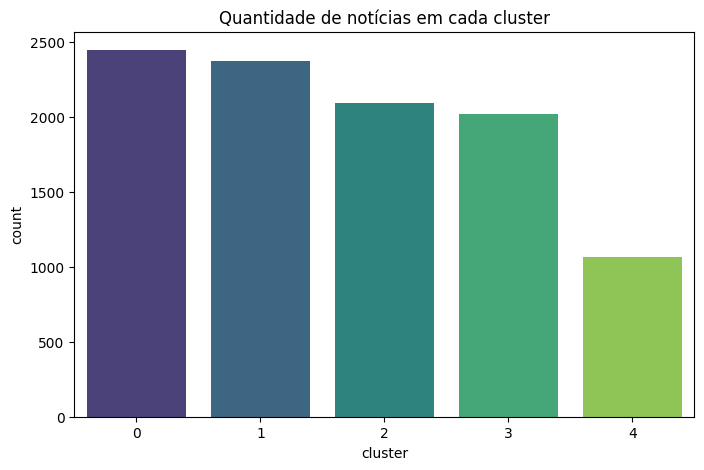

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="cluster",
    palette="viridis"
)

plt.title("Quantidade de notícias em cada cluster")

plt.show()

In [ ]:
pca2 = PCA(
    n_components=2,
    random_state=42
)

embeddings_2d = pca2.fit_transform(
    embeddings_pca
)

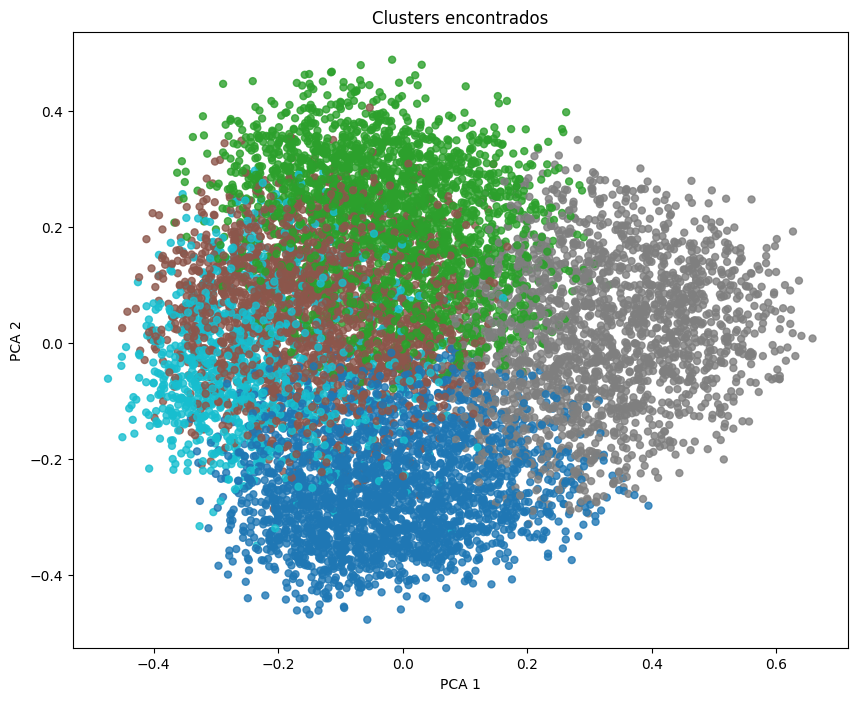

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=df["cluster"],
    cmap="tab10",
    s=25,
    alpha=0.8
)

plt.title("Clusters encontrados")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

In [ ]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_umap = reducer.fit_transform(
    embeddings
)

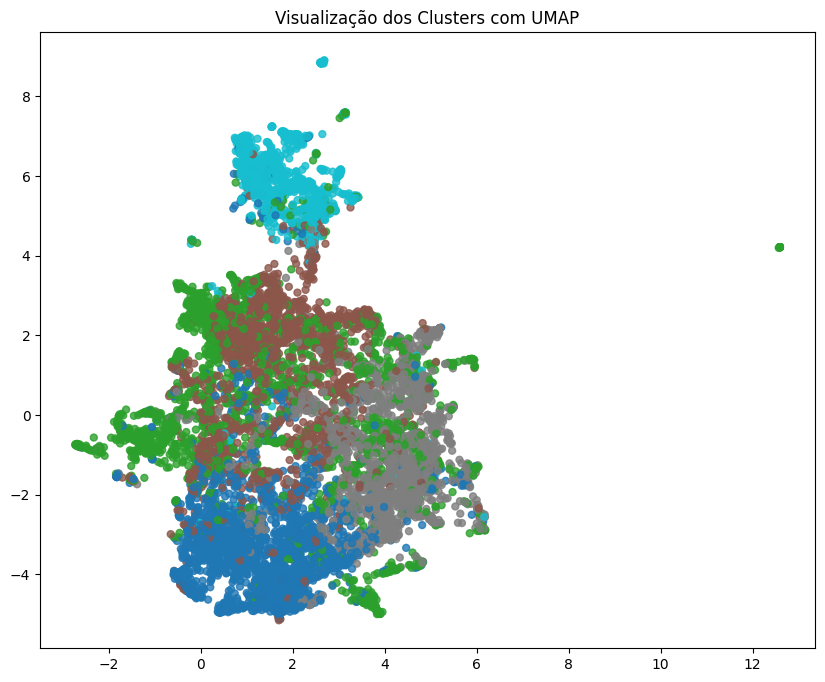

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    embedding_umap[:,0],
    embedding_umap[:,1],
    c=df["cluster"],
    cmap="tab10",
    s=25,
    alpha=0.8
)

plt.title("Visualização dos Clusters com UMAP")

plt.show()

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words=stop_words,
    max_features=3000,
    min_df=3,
    max_df=0.80
)

tfidf = vectorizer.fit_transform(df["texto_limpo"])

termos = np.array(vectorizer.get_feature_names_out())

In [ ]:
def palavras_cluster(cluster):

    indices = df[df["cluster"] == cluster].index

    medias = tfidf[indices].mean(axis=0)

    medias = np.asarray(medias).ravel()

    top = medias.argsort()[-15:][::-1]

    return termos[top]

In [ ]:
for cluster in sorted(df["cluster"].unique()):

    print("=" * 80)
    print(f"CLUSTER {cluster}")
    print("=" * 80)

    print("\nPalavras mais importantes:")
    print(", ".join(palavras_cluster(cluster)))

    print("\nExemplos de notícias:")

    exemplos = df[df["cluster"] == cluster]["title"].head(5)

    for titulo in exemplos:
        print(f"- {titulo}")

    print("\n")

CLUSTER 0

Palavras mais importantes:
presidente, dilma, governo, temer, federal, ex, ministro, nesta, feira, pmdb, câmara, lula, pt, tribunal, justiça

Exemplos de notícias:
- Joesley diz ter pensado que ex-procurador Miller era infiltrado de Janot
- Eleição confirma retorno do Syriza, de esquerda, ao poder na Grécia
- Governo propõe privatização da Eletrobras
- PSDB, Aécio, presidentes e presidiários
- Comissão aprova PEC do teto com folga e rejeita destaques da oposição


CLUSTER 1

Palavras mais importantes:
trump, anos, feira, sobre, nesta, eua, pessoas, após, mundo, filme, disse, nova, dia, país, norte

Exemplos de notícias:
- Em 'Fahrenheit 451', obra de Ray Bradbury, livros são ameaças sociais
- Eleitores se identificaram com Trump e sentiram na própria pele ataque a ele
- Israel inicia construção da primeira colônia na Cisjordânia em 25 anos
- Dependemos da arte francesa como um viciado das drogas, diz Sokurov
- Alemanha prepara pacote de medidas antiterror após série de atent

In [ ]:
tabela = pd.crosstab(
    df["cluster"],
    df["category"]
)

tabela

category,ambiente,asmais,banco-de-dados,bbc,cenarios-2017,ciencia,colunas,comida,cotidiano,dw,...,saopaulo,seminariosfolha,serafina,sobretudo,tec,topofmind,treinamentocienciaesaude,turismo,tv,vice
cluster,,,,,,,,,,,,,,,,,,,,,
0,1,2,3,2,0,3,358,0,164,0,...,1,1,0,0,3,0,0,1,34,0
1,9,8,0,31,1,49,311,12,63,4,...,15,0,6,7,104,1,0,42,34,6
2,4,6,0,11,1,10,195,21,511,1,...,174,4,9,31,12,3,0,56,48,1
3,20,5,1,12,1,35,364,2,234,0,...,12,22,2,28,15,4,1,15,21,2
4,0,9,0,0,0,0,61,1,8,0,...,7,0,1,2,1,0,0,1,8,0


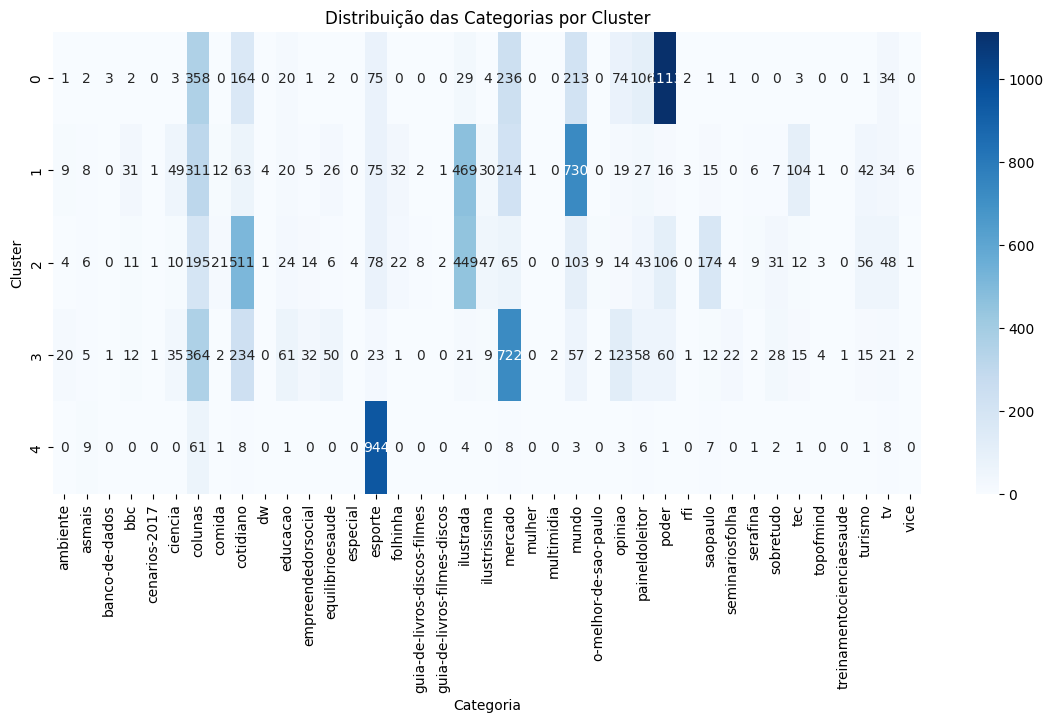

In [ ]:
plt.figure(figsize=(14,6))

sns.heatmap(
    tabela,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Distribuição das Categorias por Cluster")

plt.xlabel("Categoria")

plt.ylabel("Cluster")

plt.show()

In [ ]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorias = encoder.fit_transform(df["category"])

In [ ]:
ari = adjusted_rand_score(
    categorias,
    df["cluster"]
)

print("Adjusted Rand Index:",round(ari,3))

Adjusted Rand Index: 0.194


In [ ]:
nmi = normalized_mutual_info_score(
    categorias,
    df["cluster"]
)

print("Normalized Mutual Information:",round(nmi,3))

Normalized Mutual Information: 0.269


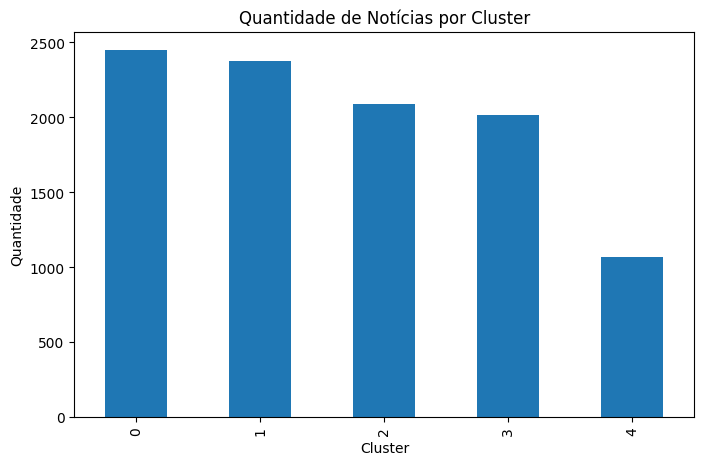

In [ ]:
plt.figure(figsize=(8,5))

df["cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Quantidade de Notícias por Cluster")

plt.xlabel("Cluster")

plt.ylabel("Quantidade")

plt.show()

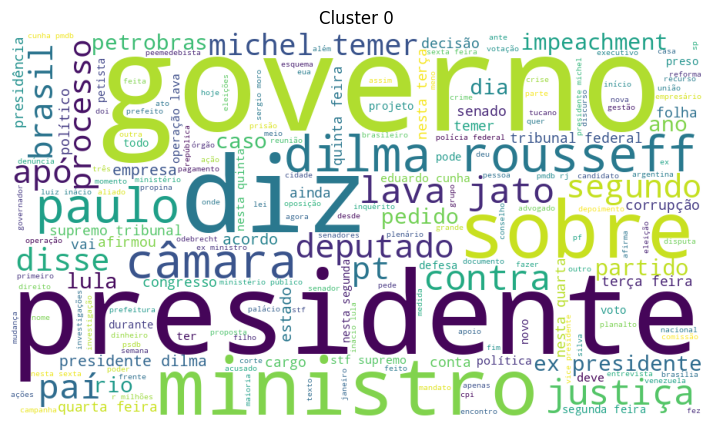

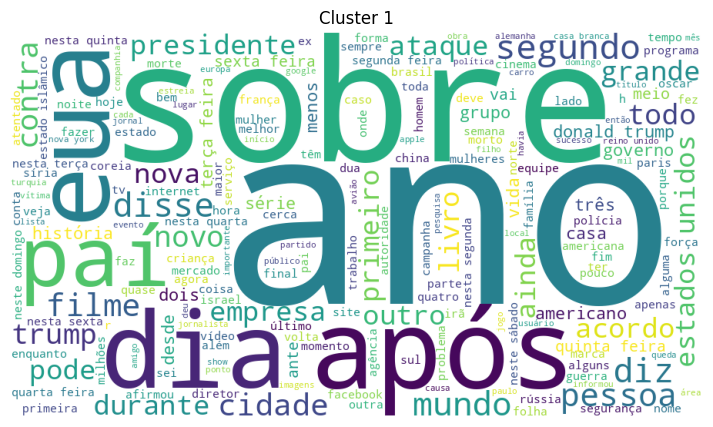

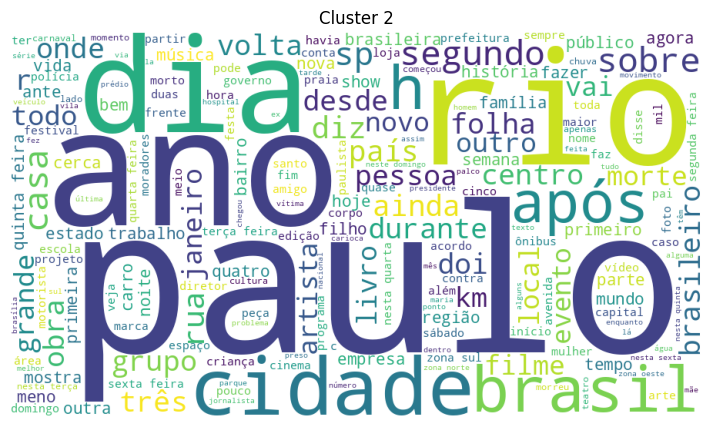

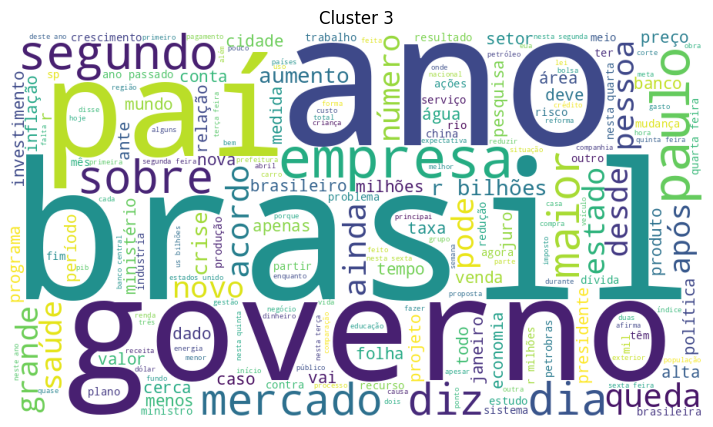

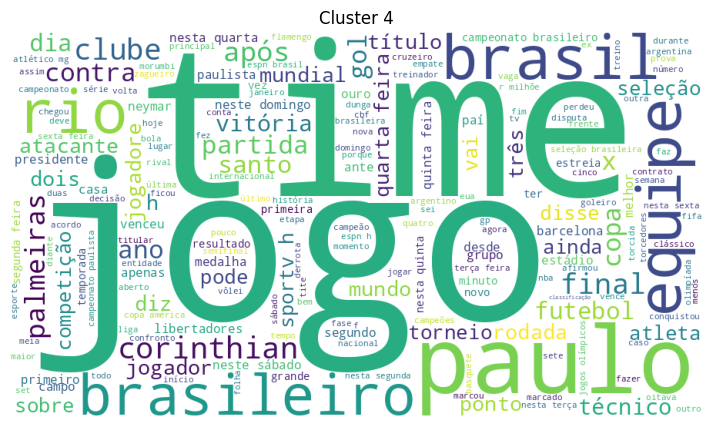

In [ ]:
for cluster in sorted(df["cluster"].unique()):

    texto = " ".join(
        df[df["cluster"]==cluster]["texto_limpo"]
    )

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        stopwords=stop_words
    ).generate(texto)

    plt.figure(figsize=(12,5))

    plt.imshow(wc)

    plt.axis("off")

    plt.title(f"Cluster {cluster}")

    plt.show()

In [ ]:
resumo = []

for cluster in sorted(df["cluster"].unique()):

    quantidade = len(df[df["cluster"]==cluster])

    categoria = (
        df[df["cluster"]==cluster]["category"]
        .value_counts()
        .idxmax()
    )

    resumo.append([
        cluster,
        quantidade,
        categoria,
        ", ".join(palavras_cluster(cluster)[:5])
    ])

resumo = pd.DataFrame(
    resumo,
    columns=[
        "Cluster",
        "Qtd Notícias",
        "Categoria predominante",
        "Principais palavras"
    ]
)

resumo

,Cluster,Qtd Notícias,Categoria predominante,Principais palavras
0,0,2448,poder,"presidente, dilma, governo, temer, federal"
1,1,2373,mundo,"trump, anos, feira, sobre, nesta"
2,2,2092,cotidiano,"paulo, rio, anos, cidade, dia"
3,3,2018,mercado,"ano, brasil, governo, país, bilhões"
4,4,1069,esporte,"time, corinthians, copa, brasileiro, palmeiras"
